# III. Bivariate Analysis

This notebook explores relationships between key marketing variables to uncover business insights.

Analyses included:
- Channel efficiency using ROI distributions by channel
- Audience targeting performance using average conversion rate
- Correlation structure across numerical campaign metrics
- Statistical significance test for ROI differences between Google Ads and YouTube

Assumption: the cleaned dataset has been generated by `02_clean_and_validate.ipynb`.

In [59]:
# Core analysis stack for bivariate plots, summaries, and hypothesis testing.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Shared plotting defaults keep figure styling consistent across sections.
plt.style.use("dark_background")
sns.set_theme(style="darkgrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.facecolor"] = "#121212"
plt.rcParams["figure.facecolor"] = "#121212"
plt.rcParams["savefig.facecolor"] = "#121212"
plt.rcParams["savefig.edgecolor"] = "#121212"
plt.rcParams["axes.edgecolor"] = "#E0E0E0"
plt.rcParams["axes.labelcolor"] = "#F5F5F5"
plt.rcParams["xtick.color"] = "#E0E0E0"
plt.rcParams["ytick.color"] = "#E0E0E0"
plt.rcParams["text.color"] = "#F5F5F5"
plt.rcParams["grid.color"] = "#3A3A3A"


In [60]:
from pathlib import Path


# Expected cleaned input generated by notebook 2.
cleaned_dataset_path = Path("../datasets/cleaned_marketing_dataset.csv")
results_dir = Path("../results/bivariate_analysis")
# Ensure chart export directory exists before plotting steps run.
results_dir.mkdir(parents=True, exist_ok=True)


# Remove legacy dark-suffixed charts so each figure is kept only once.
for legacy_chart in results_dir.glob("*_dark.png"):
    legacy_chart.unlink(missing_ok=True)


# Fail fast with a clear dependency message if the file is missing.
if not cleaned_dataset_path.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found at: {cleaned_dataset_path.resolve()}\n"
        "Run the cleaning pipeline first (02_clean_and_validate.ipynb)."
    )


# Parse `Date` on load so time-aware follow-ups are immediately available.
df = pd.read_csv(cleaned_dataset_path, parse_dates=["Date"])
print(f"Loaded dataframe shape: {df.shape}")
print(f"Source file: {cleaned_dataset_path.resolve()}")
print(f"Charts will be saved to: {results_dir.resolve()}")
# Quick preview to confirm field layout before analysis steps.
df.head()



Loaded dataframe shape: (200000, 16)
Source file: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\datasets\cleaned_marketing_dataset.csv
Charts will be saved to: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\bivariate_analysis


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30,Google Ads,0.04,16174.0,6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60,Google Ads,0.12,11566.0,5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30,YouTube,0.07,10200.0,7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60,YouTube,0.11,12724.0,5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15,YouTube,0.05,16452.0,6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


## Step 1: Data Validation for Required Columns

Before analysis, validate that the dataset includes the columns needed for plotting and statistical testing.

In [61]:
# Columns required by downstream plots and statistical test sections.
required_columns = [
    "Channel_Used",
    "ROI",
    "Target_Audience",
    "Conversion_Rate",
    "Acquisition_Cost",
    "Clicks",
    "Impressions",
    "Engagement_Score",
]
# Guard clause prevents partial execution with broken schema.
missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")
print("All required columns are available.")


All required columns are available.


## Step 2: Channel Efficiency

Compare ROI distributions across channels to evaluate which channel tends to deliver stronger returns.

The boxplot highlights medians, spread, and potential outliers by channel.

C:\Users\hecto\AppData\Local\Temp\ipykernel_74504\1844141788.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="Channel_Used", y="ROI", palette="Set2")


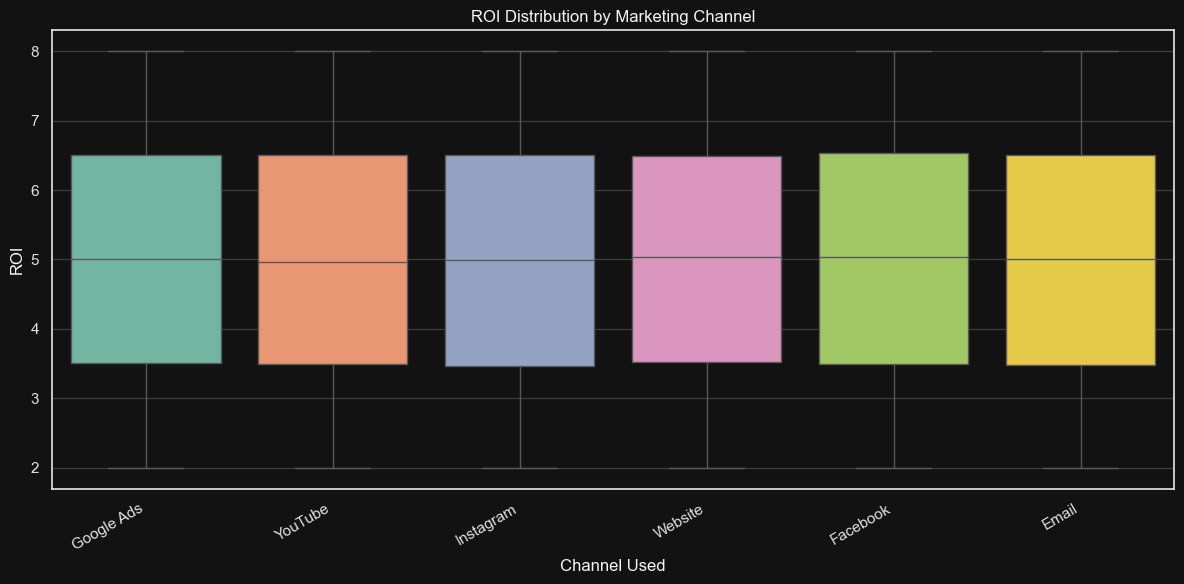

Saved: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\bivariate_analysis\roi_distribution_by_channel.png


,count,mean,median,std
Channel_Used,,,,
Facebook,32819,5.018699,5.040,1.738050
Website,33360,5.014167,5.030,1.725129
Google Ads,33438,5.003141,5.010,1.733629
Email,33599,4.996487,5.000,1.738349
Instagram,33392,4.988706,4.985,1.739413
YouTube,33392,4.993754,4.970,1.732278


In [62]:
# Keep only fields needed for this view and drop incomplete pairs.
plot_df = df[["Channel_Used", "ROI"]].dropna().copy()

# Boxplots compare central tendency, spread, and outliers across channels.
plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x="Channel_Used", y="ROI", palette="Set2")
plt.title("ROI Distribution by Marketing Channel")
plt.xlabel("Channel Used")
plt.ylabel("ROI")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
roi_plot_path = results_dir / "roi_distribution_by_channel.png"
plt.savefig(roi_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {roi_plot_path.resolve()}")

# Companion summary table ranks channels by median ROI (robust to outliers).
channel_roi_summary = (
    plot_df.groupby("Channel_Used")["ROI"]
    .agg(["count", "mean", "median", "std"])
    .sort_values(by="median", ascending=False)
)
channel_roi_summary


### Channel Efficiency Interpretation

The most cost-effective channel should be interpreted as the one with:
- The highest **median ROI** (more robust than mean against outliers), and
- A relatively stable spread (lower variability where possible).

Use the table shown above (`channel_roi_summary`) to identify the top channel after execution.

## Step 3: Audience Targeting

Compare average conversion rates by target audience to understand which audience responds best to campaigns.

C:\Users\hecto\AppData\Local\Temp\ipykernel_74504\2605697884.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


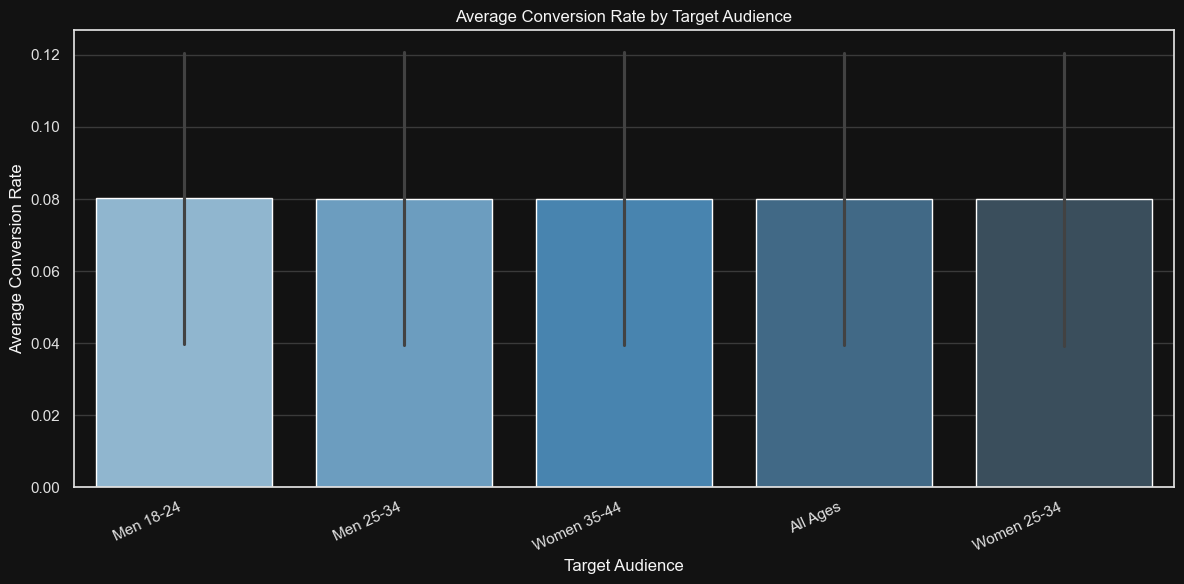

Saved: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\bivariate_analysis\avg_conversion_by_audience.png


In [63]:
# Restrict to audience/conversion fields and remove missing records.
audience_df = df[["Target_Audience", "Conversion_Rate"]].dropna().copy()

# Sort categories by mean conversion so bar order is interpretation-ready.
audience_order = (
    audience_df.groupby("Target_Audience")["Conversion_Rate"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# `errorbar="sd"` adds variability context around mean conversion rates.
plt.figure(figsize=(12, 6))
sns.barplot(
    data=audience_df,
    x="Target_Audience",
    y="Conversion_Rate",
    order=audience_order,
    estimator=np.mean,
    errorbar="sd",
    palette="Blues_d"
)
plt.title("Average Conversion Rate by Target Audience")
plt.xlabel("Target Audience")
plt.ylabel("Average Conversion Rate")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
audience_plot_path = results_dir / "avg_conversion_by_audience.png"
plt.savefig(audience_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {audience_plot_path.resolve()}")

## Step 4: Correlation Analysis

Evaluate linear relationships among key numerical metrics to detect trade-offs and synergies across campaign performance indicators.

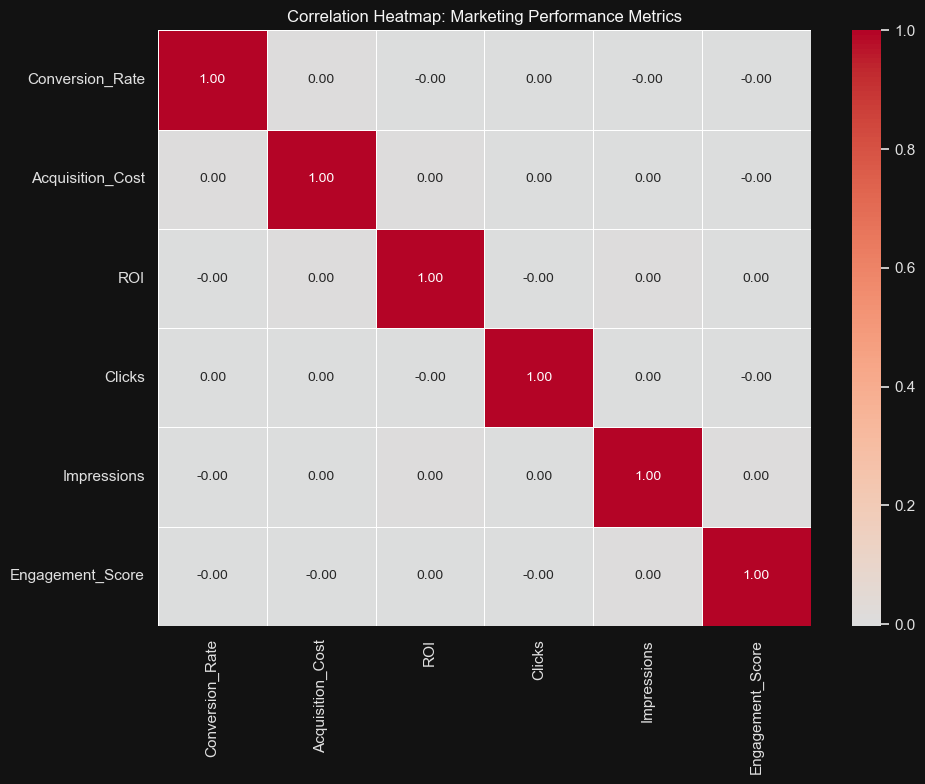

Saved: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\bivariate_analysis\correlation_heatmap.png


In [64]:
# Focus correlation on core numeric KPIs used in campaign performance review.
num_cols = [
    "Conversion_Rate",
    "Acquisition_Cost",
    "ROI",
    "Clicks",
    "Impressions",
    "Engagement_Score",
]
corr_df = df[num_cols].copy()

# Pearson correlation matrix reveals linear co-movement patterns.
corr_matrix = corr_df.corr(numeric_only=True)

# Center heatmap at zero to make positive/negative directions visually symmetric.
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 10}
)
plt.title("Correlation Heatmap: Marketing Performance Metrics")
plt.tight_layout()
corr_plot_path = results_dir / "correlation_heatmap.png"
plt.savefig(corr_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {corr_plot_path.resolve()}")

## Step 5: Statistical Significance: Google Ads vs YouTube ROI

Use a two-sample Welch's t-test to compare average ROI between **Google Ads** and **YouTube**.

- Null hypothesis (`H0`): the mean ROI is equal for both channels.
- Alternative hypothesis (`H1`): the mean ROI differs between channels.

In [65]:
# Conventional significance level for the two-sample comparison.
alpha = 0.05

# Extract channel-specific ROI samples and drop missing values.
google_roi = df.loc[df["Channel_Used"] == "Google Ads", "ROI"].dropna()
youtube_roi = df.loc[df["Channel_Used"] == "YouTube", "ROI"].dropna()

# Welch t-test requires at least two observations per group.
if len(google_roi) < 2 or len(youtube_roi) < 2:
    raise ValueError(
        f"Insufficient data for t-test. Google Ads n={len(google_roi)}, YouTube n={len(youtube_roi)}"
    )

# `equal_var=False` applies Welch's correction for unequal variances.
t_stat, p_value = stats.ttest_ind(google_roi, youtube_roi, equal_var=False)
print(f"Google Ads sample size: {len(google_roi)}")
print(f"YouTube sample size: {len(youtube_roi)}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Report an interpretation-ready decision against alpha.
if p_value < alpha:
    print(
        f"Result: Statistically significant difference in ROI between Google Ads and YouTube (p < {alpha})."
    )
else:
    print(
        f"Result: No statistically significant ROI difference between Google Ads and YouTube (p >= {alpha})."
    )

Google Ads sample size: 33438
YouTube sample size: 33392
T-statistic: 0.7002
P-value: 0.483825
Result: No statistically significant ROI difference between Google Ads and YouTube (p >= 0.05).


## Summarized data

In [66]:
# Lightweight text audit for logs/CI where chart rendering is unavailable.
# Temporary audit cell for concise notebook-3 insights
channel_roi_summary_local = (
    df[["Channel_Used", "ROI"]]
    .dropna()
    .groupby("Channel_Used")["ROI"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("median", ascending=False)
)
audience_conversion_local = (
    df[["Target_Audience", "Conversion_Rate"]]
    .dropna()
    .groupby("Target_Audience")["Conversion_Rate"]
    .agg(["count", "mean", "std"])
    .sort_values("mean", ascending=False)
)

# Rank strongest linear relationships by absolute correlation magnitude.
corr_matrix_local = df[["Conversion_Rate", "Acquisition_Cost", "ROI", "Clicks", "Impressions", "Engagement_Score"]].corr(numeric_only=True)
abs_corr_pairs = (
    corr_matrix_local.where(~np.eye(corr_matrix_local.shape[0], dtype=bool))
    .stack()
    .abs()
    .sort_values(ascending=False)
)
print("CHANNEL_ROI_SUMMARY")
print(channel_roi_summary_local.to_string())
print("\nAUDIENCE_CONVERSION_SUMMARY")
print(audience_conversion_local.to_string())
print("\nTOP_ABS_CORR_PAIRS")
print(abs_corr_pairs.head(6).to_string())

# Reproduce Welch t-test in compact text format for downstream reporting.
google_roi_local = df.loc[df["Channel_Used"] == "Google Ads", "ROI"].dropna()
youtube_roi_local = df.loc[df["Channel_Used"] == "YouTube", "ROI"].dropna()
t_stat_local, p_value_local = stats.ttest_ind(google_roi_local, youtube_roi_local, equal_var=False)
print("\nTTEST")
print(f"google_n={len(google_roi_local)}, youtube_n={len(youtube_roi_local)}, t_stat={t_stat_local:.6f}, p_value={p_value_local:.6f}")

# Build one exportable summary table in long format (section + metric + value).
summary_rows = []
for channel, row in channel_roi_summary_local.iterrows():
    summary_rows.extend([
        {"section": "channel_roi", "group": channel, "metric": "count", "value": row["count"]},
        {"section": "channel_roi", "group": channel, "metric": "mean", "value": row["mean"]},
        {"section": "channel_roi", "group": channel, "metric": "median", "value": row["median"]},
        {"section": "channel_roi", "group": channel, "metric": "std", "value": row["std"]},
    ])
for audience, row in audience_conversion_local.iterrows():
    summary_rows.extend([
        {"section": "audience_conversion", "group": audience, "metric": "count", "value": row["count"]},
        {"section": "audience_conversion", "group": audience, "metric": "mean", "value": row["mean"]},
        {"section": "audience_conversion", "group": audience, "metric": "std", "value": row["std"]},
    ])
for pair, corr_value in abs_corr_pairs.head(6).items():
    summary_rows.append(
        {
            "section": "top_abs_correlation",
            "group": f"{pair[0]}__{pair[1]}",
            "metric": "abs_corr",
            "value": corr_value,
        }
    )
summary_rows.extend([
    {"section": "ttest_google_vs_youtube", "group": "google_vs_youtube", "metric": "google_n", "value": len(google_roi_local)},
    {"section": "ttest_google_vs_youtube", "group": "google_vs_youtube", "metric": "youtube_n", "value": len(youtube_roi_local)},
    {"section": "ttest_google_vs_youtube", "group": "google_vs_youtube", "metric": "t_stat", "value": t_stat_local},
    {"section": "ttest_google_vs_youtube", "group": "google_vs_youtube", "metric": "p_value", "value": p_value_local},
])
final_summary_csv = pd.DataFrame(summary_rows)
summary_csv_path = results_dir / "bivariate_final_summary.csv"
final_summary_csv.to_csv(summary_csv_path, index=False)
print(f"\nSaved summary CSV: {summary_csv_path.resolve()}")
final_summary_csv.head(12)

CHANNEL_ROI_SUMMARY
              count      mean  median       std
Channel_Used                                   
Facebook      32819  5.018699   5.040  1.738050
Website       33360  5.014167   5.030  1.725129
Google Ads    33438  5.003141   5.010  1.733629
Email         33599  4.996487   5.000  1.738349
Instagram     33392  4.988706   4.985  1.739413
YouTube       33392  4.993754   4.970  1.732278

AUDIENCE_CONVERSION_SUMMARY
                 count      mean       std
Target_Audience                           
Men 18-24        40258  0.080240  0.040417
Men 25-34        40023  0.080132  0.040579
Women 35-44      39687  0.080102  0.040687
All Ages         40019  0.079975  0.040563
Women 25-34      40013  0.079899  0.040764

TOP_ABS_CORR_PAIRS
ROI               Acquisition_Cost    0.004585
Acquisition_Cost  ROI                 0.004585
                  Engagement_Score    0.003218
Engagement_Score  Acquisition_Cost    0.003218
Impressions       Engagement_Score    0.003030
Engagement_

,section,group,metric,value
0,channel_roi,Facebook,count,32819.000000
1,channel_roi,Facebook,mean,5.018699
2,channel_roi,Facebook,median,5.040000
3,channel_roi,Facebook,std,1.738050
4,channel_roi,Website,count,33360.000000
5,channel_roi,Website,mean,5.014167
6,channel_roi,Website,median,5.030000
7,channel_roi,Website,std,1.725129
8,channel_roi,Google Ads,count,33438.000000
9,channel_roi,Google Ads,mean,5.003141


Bivariate artifacts saved in this notebook:
- C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\bivariate_analysis\bivariate_final_summary.csv
- C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\bivariate_analysis\avg_conversion_by_audience.png
- C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\bivariate_analysis\correlation_heatmap.png
- C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\bivariate_analysis\roi_distribution_by_channel.png


### `bivariate_final_summary.csv`

,section,group,metric,value
0,channel_roi,Facebook,count,32819.000000
1,channel_roi,Facebook,mean,5.018699
2,channel_roi,Facebook,median,5.040000
3,channel_roi,Facebook,std,1.738050
4,channel_roi,Website,count,33360.000000
5,channel_roi,Website,mean,5.014167
6,channel_roi,Website,median,5.030000
7,channel_roi,Website,std,1.725129
8,channel_roi,Google Ads,count,33438.000000
9,channel_roi,Google Ads,mean,5.003141


### `avg_conversion_by_audience.png`

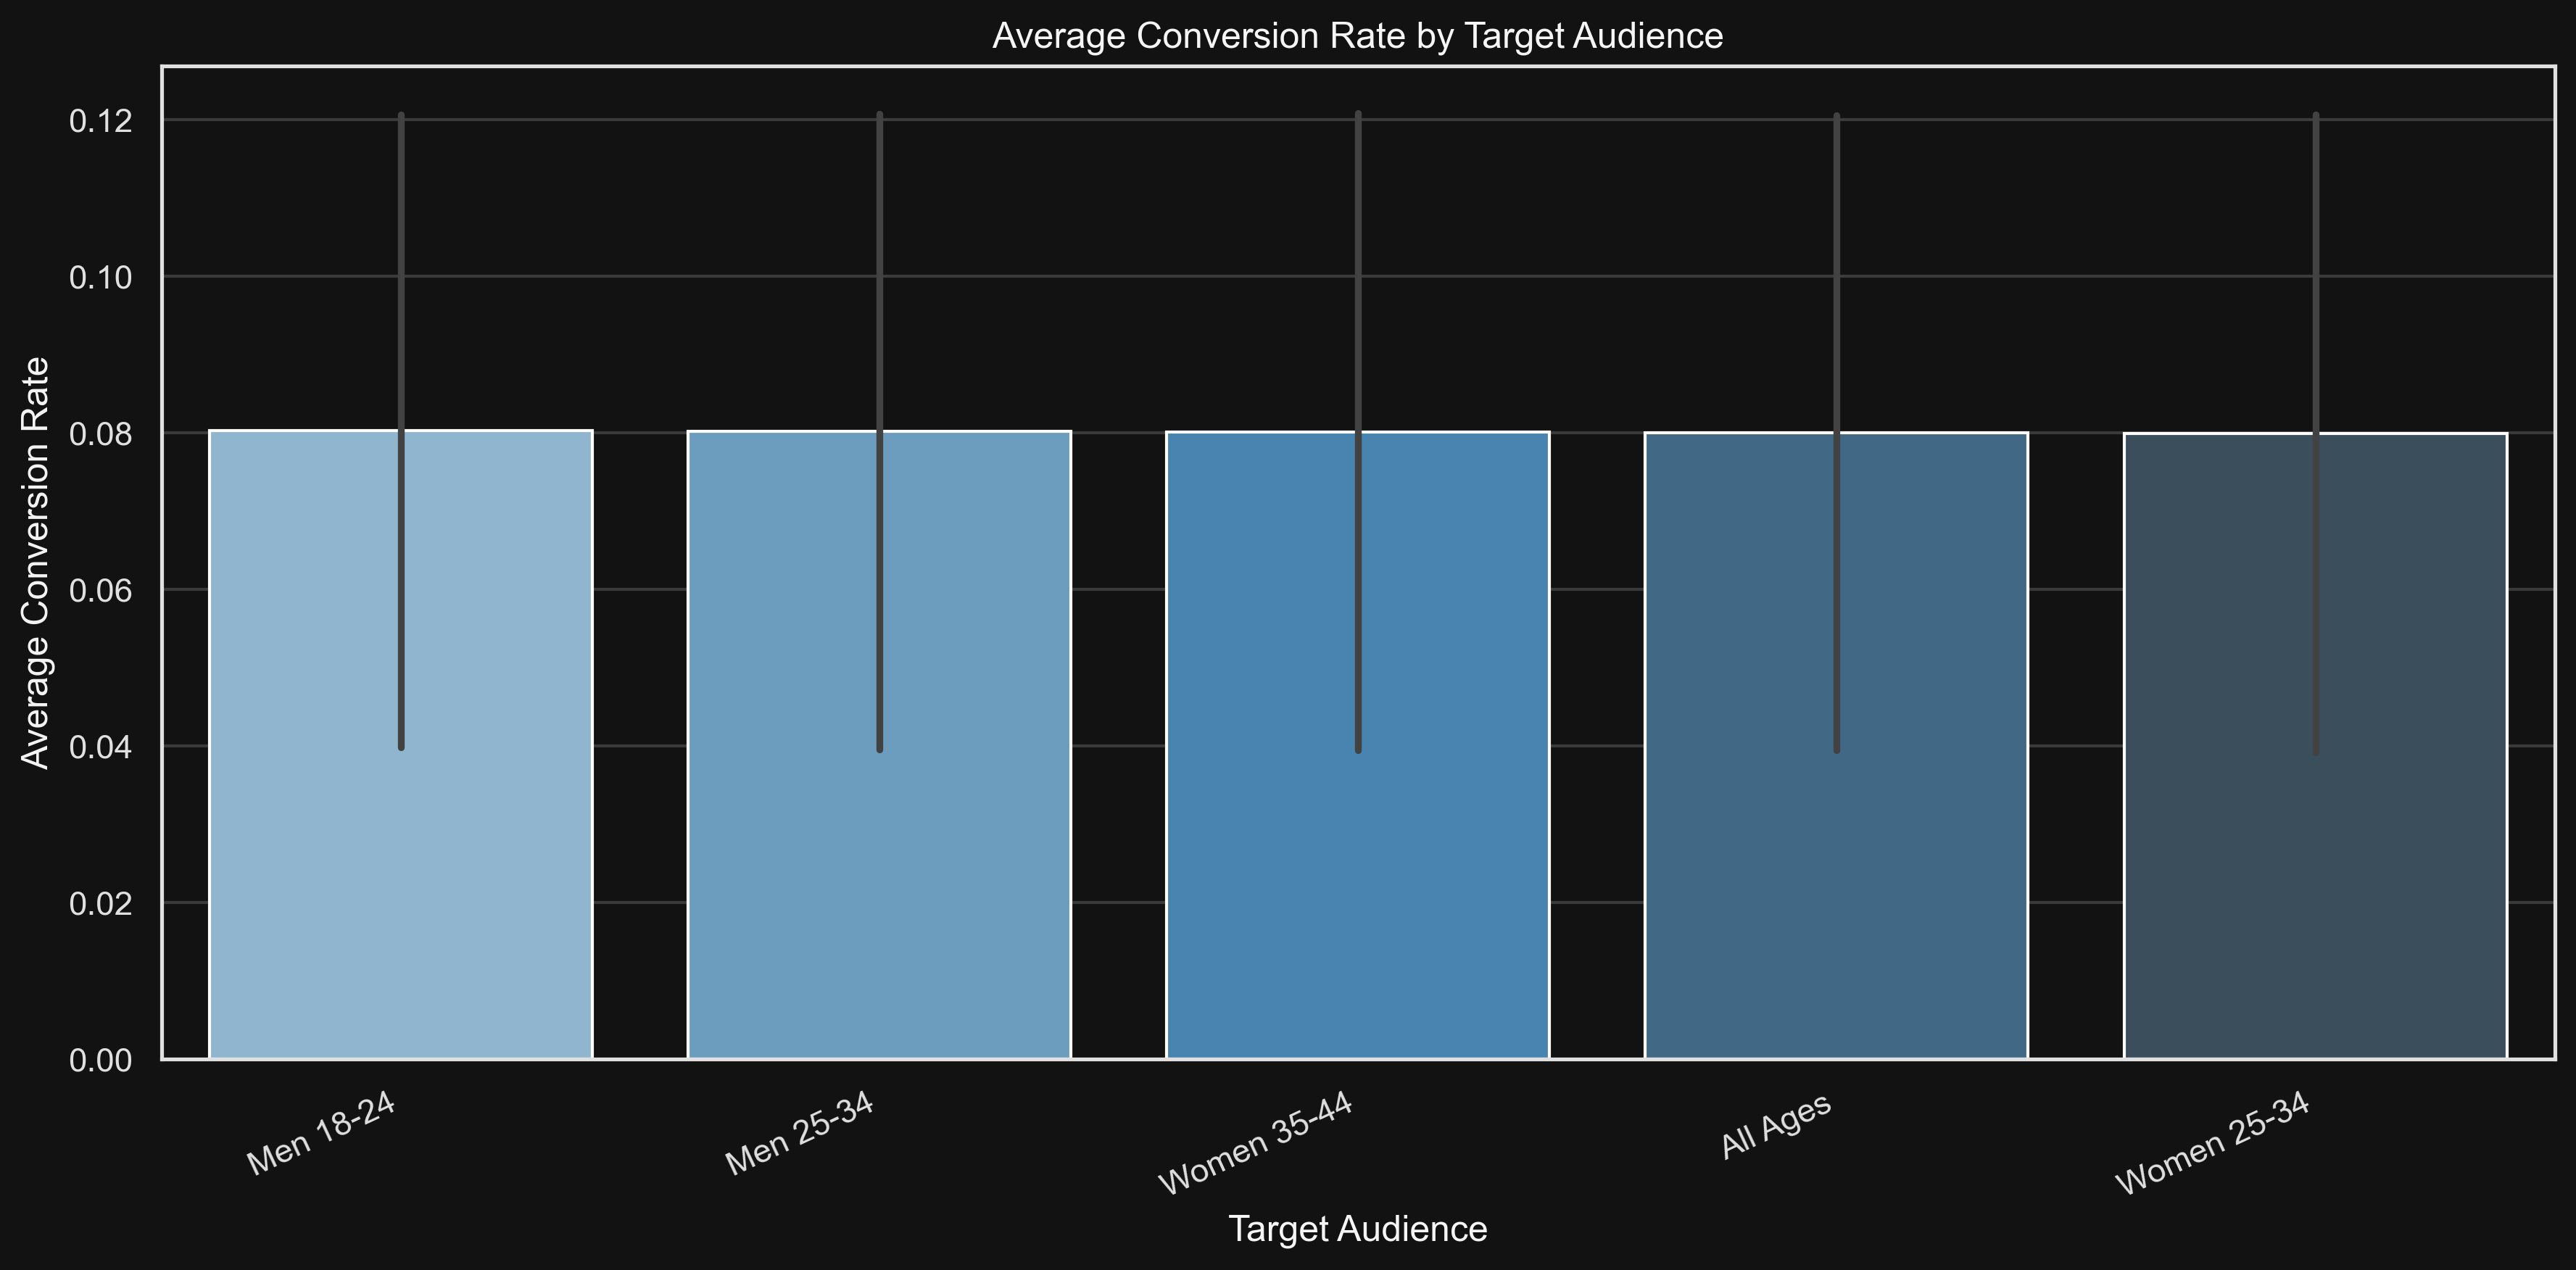

### `correlation_heatmap.png`

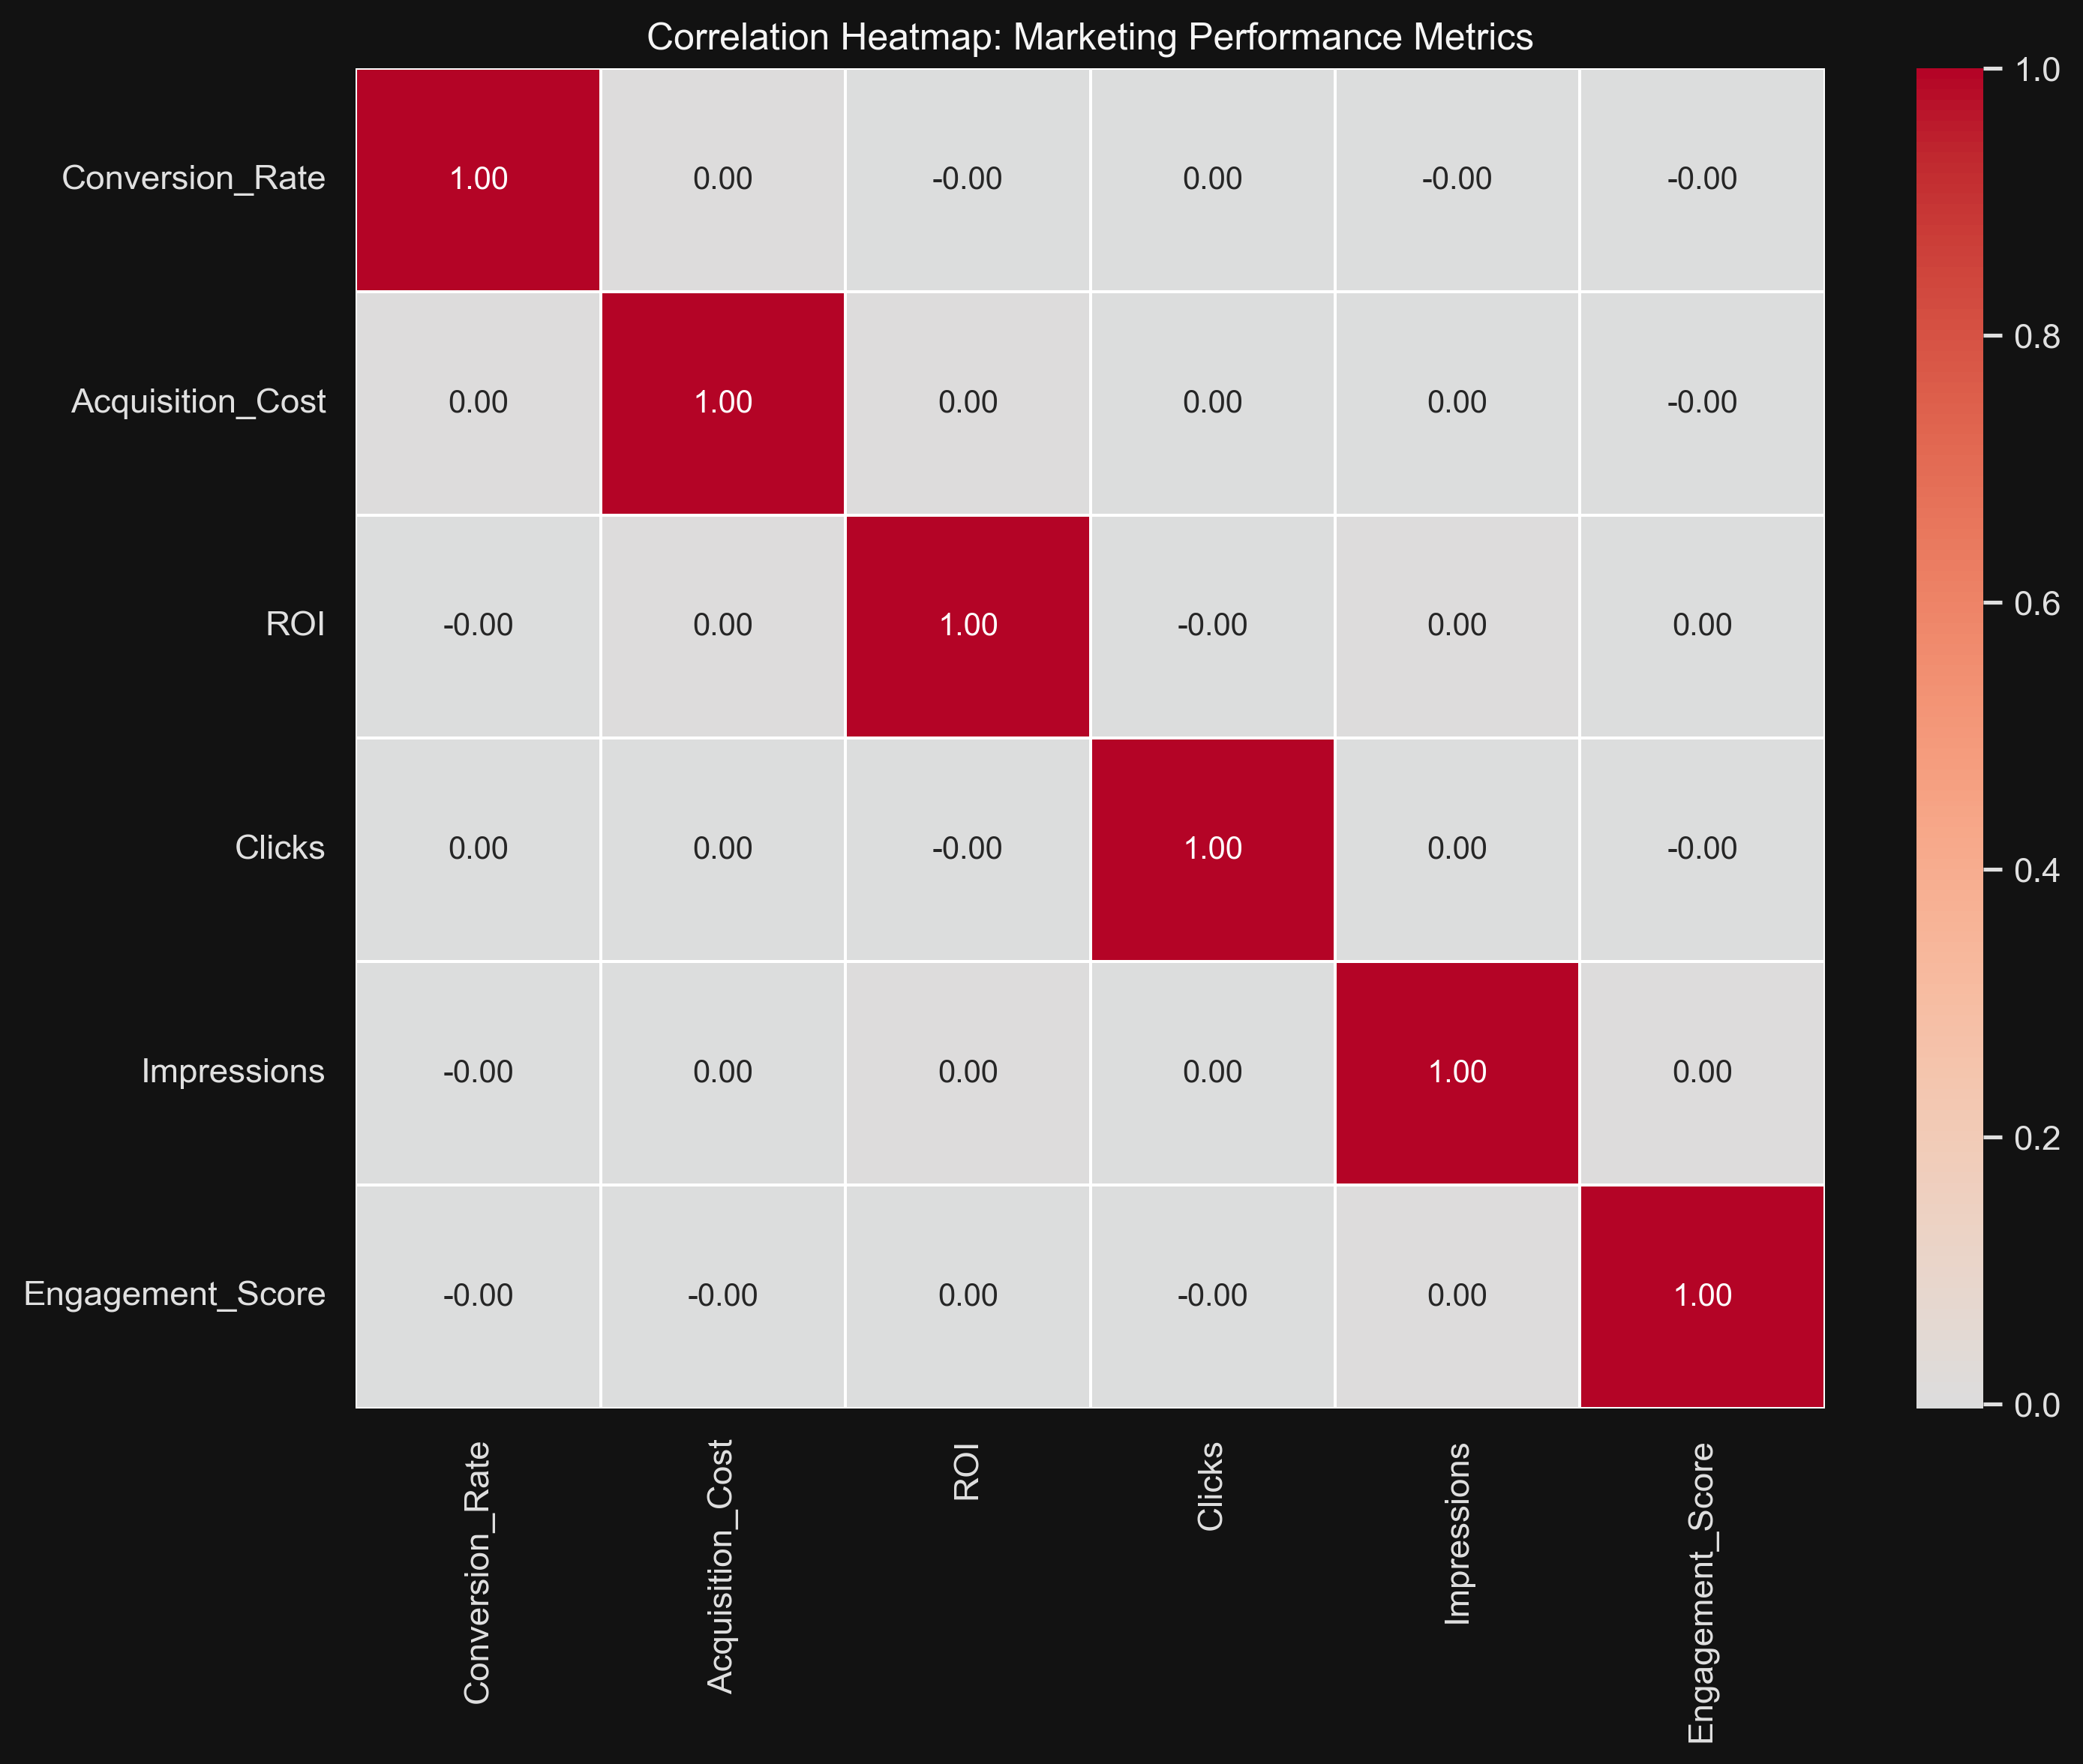

### `roi_distribution_by_channel.png`

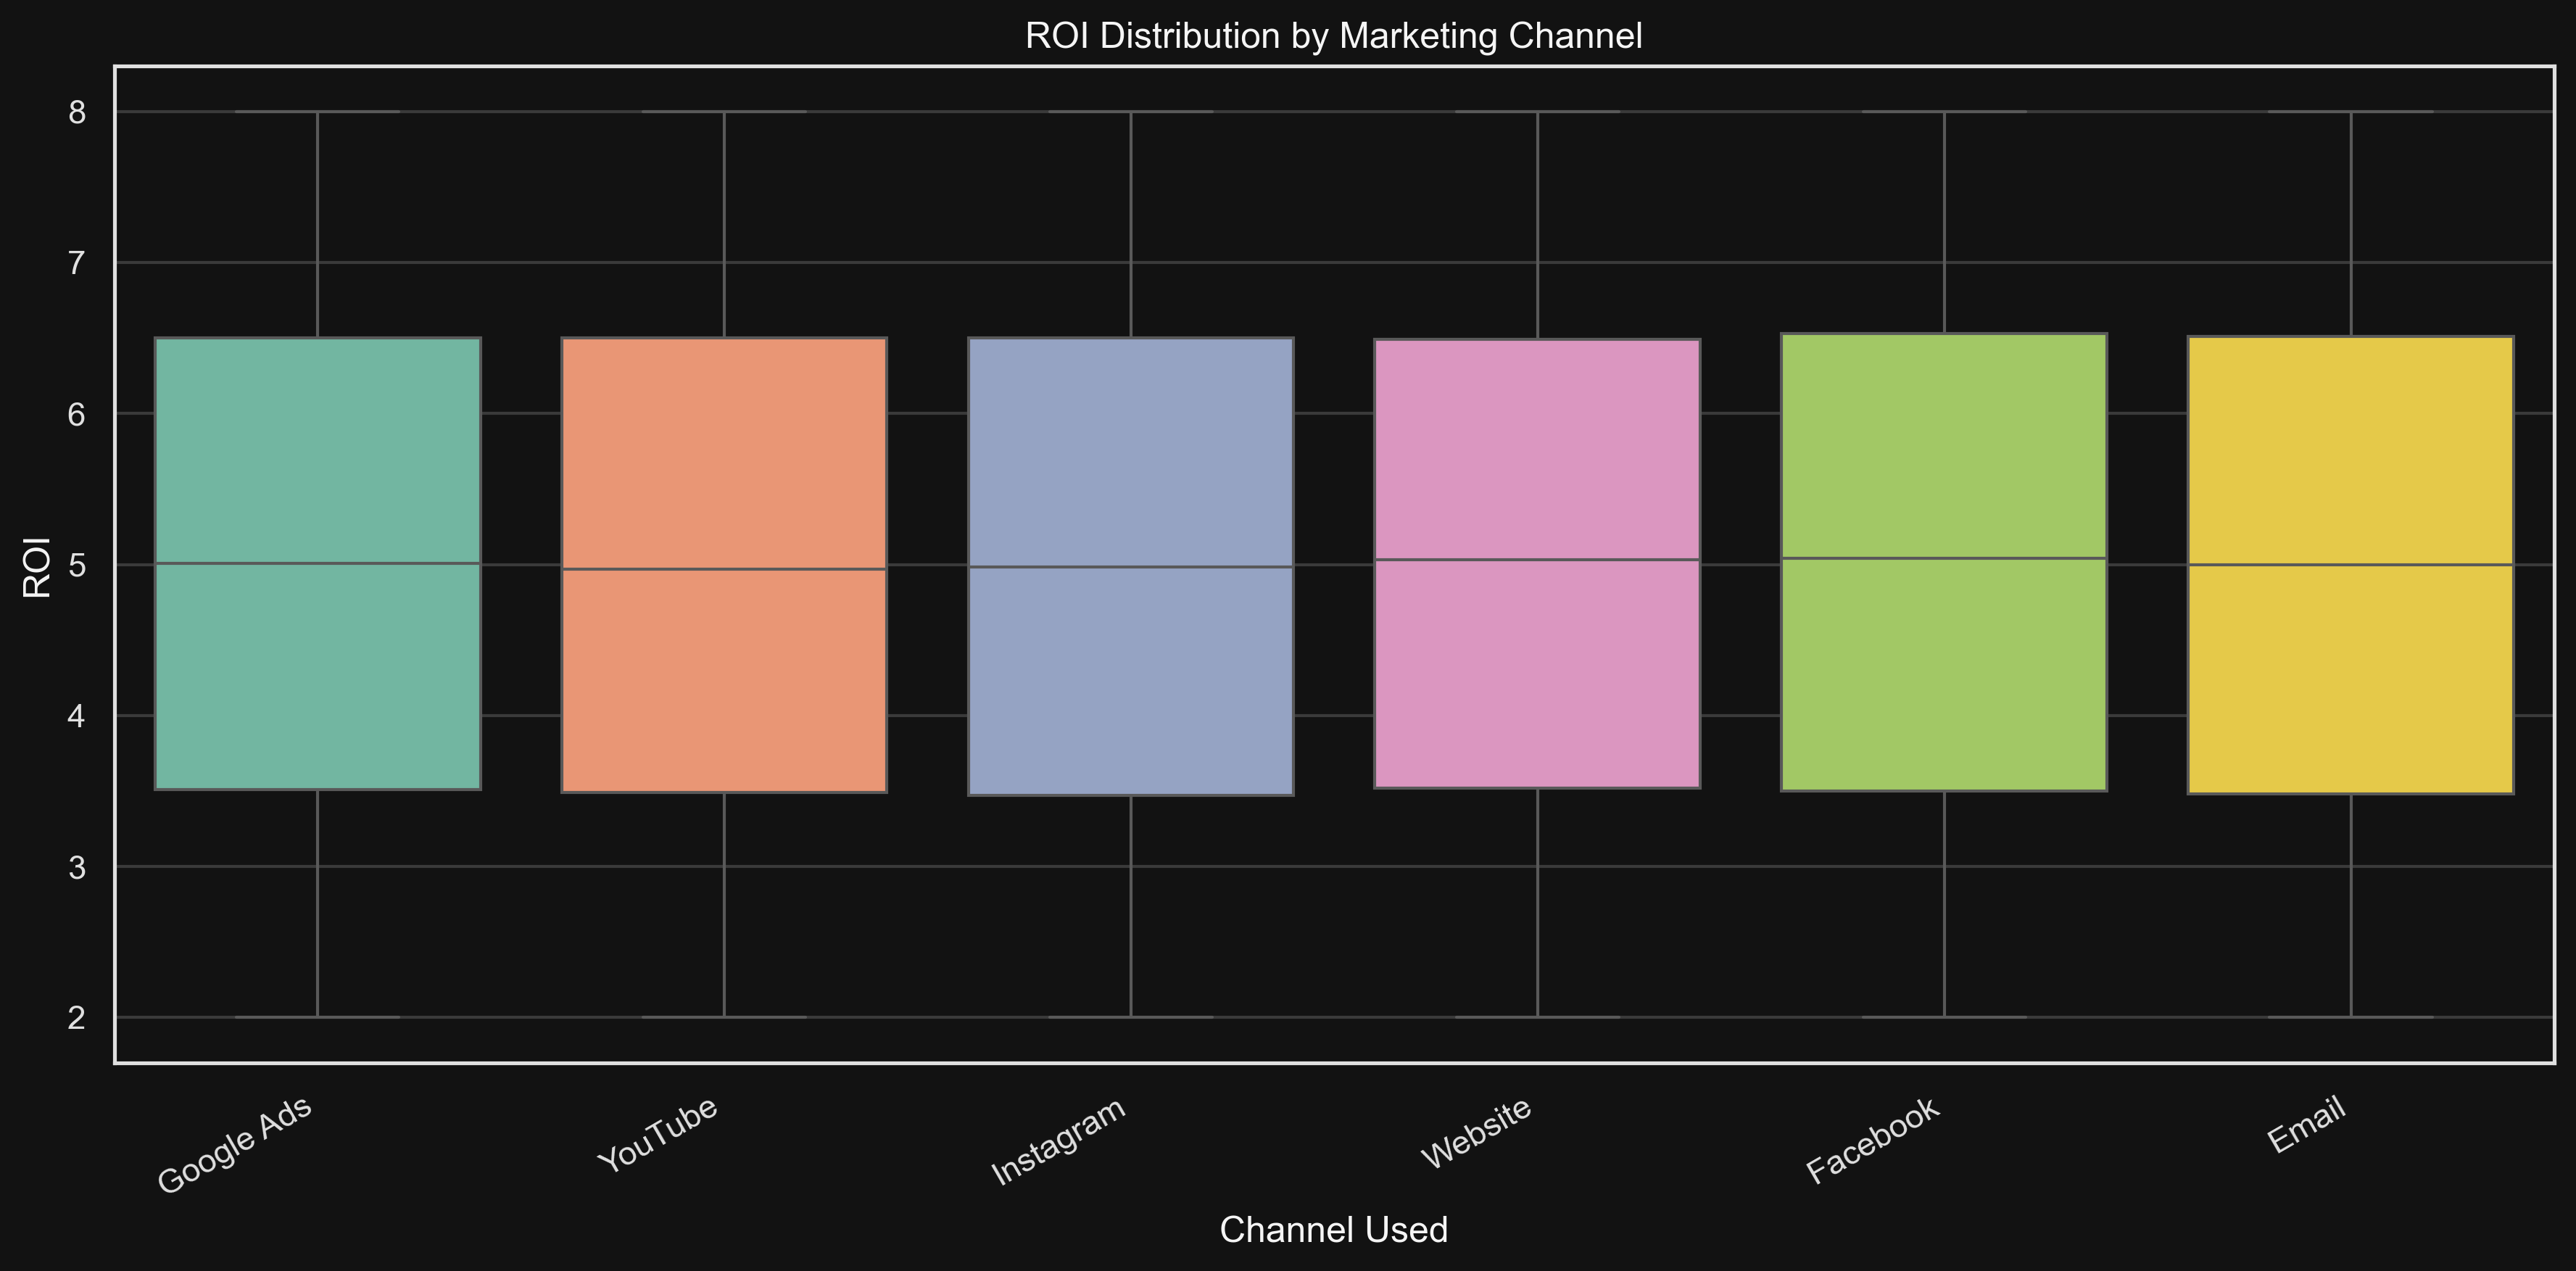

In [67]:
from IPython.display import Image, Markdown, display
# Final artifact check before the concluding summary.
saved_tables = sorted(results_dir.glob("*.csv"))
saved_charts = sorted(p for p in results_dir.glob("*.png") if not p.name.endswith("_dark.png"))
if not saved_tables and not saved_charts:
    print("No saved artifacts found yet. Run the analysis cells first.")
else:
    print("Bivariate artifacts saved in this notebook:")
    for table_path in saved_tables:
        print(f"- {table_path.resolve()}")
    for chart_path in saved_charts:
        print(f"- {chart_path.resolve()}")
# Preview saved CSV tables.
for table_path in saved_tables:
    display(Markdown(f"### `{table_path.name}`"))
    display(pd.read_csv(table_path))
# Preview saved charts.
for chart_path in saved_charts:
    display(Markdown(f"### `{chart_path.name}`"))
    display(Image(filename=str(chart_path)))



## Executive Summary

The bivariate analysis indicates highly homogeneous performance across both marketing channels and audience segments. Average ROI is tightly clustered (approximately 4.99-5.02) with similar dispersion across channels, suggesting no materially superior channel based on ROI alone. Conversion rates by audience segment are likewise nearly identical (around 0.08), with only marginal differences that are unlikely to be operationally meaningful.

Statistical testing confirms this pattern: the Google Ads vs YouTube ROI comparison is not significant (p = 0.4838), and the strongest pairwise correlations among key numeric variables are near zero (|r| < 0.005), indicating no meaningful linear bivariate relationships.

Overall, these results suggest that major performance improvements are unlikely to come from simple channel or broad audience reallocation; stronger gains will likely require multivariate targeting, creative experimentation, and funnel/cost optimization.